In [70]:
import os
import pandas as pd
import numpy as np
import torch

from transformers import AutoTokenizer, AutoConfig, AutoModelForSequenceClassification
from scipy.special import softmax

In [71]:
model_name = "cardiffnlp/twitter-roberta-base-topic-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_name)
config = AutoConfig.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Mudeli sildid: "id2label": { "0": "strongly negative", "1": "negative", "2": "negative or neutral", "3": "positive", "4": "strongly positive" }
labels = config.id2label

# Siltide teisendamine numbriliseks skooriks, et hiljem arvutusi teha.
label_to_score = {
    "strongly negative": -2.0,
    "negative": -1.0,
    "negative or neutral": 0.0,
    "positive": 1.0,
    "strongly positive": 2.0
}

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 938.92it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-topic-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [72]:
# Ennustab teksti meelestatuse antud väärtuse suhtes. 
# sisend: tekst ja väärtus
# väljund: ennustatud meelestatus, selle numbriline skoor ning tõenäosused iga silid kohta.
def target_sentiment(text, target):

    # Kui tekst puudub määrame teksti neutraalseks.
    if not text:
        return {
            "label": "negative or neutral",
            "numeric_score": 0.0,
            "strongly negative": 0.0,
            "negative": 0.0,
            "negative or neutral": 1.0,
            "positive": 0.0,
            "strongly positive": 0.0
        }

    # Mudeli sisend
    model_text = f"{text} </s> {target}"

    encoded = tokenizer(
        model_text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # Jätame gradientide  arvutamise ära, sest me ei treeni mudelit, vaid kasutame seda ainult ennustamiseks.
    with torch.no_grad():
        output = model(**encoded)

    # Teisendame mudeli väljundid softmaxi abil 0-1 vahemikku.
    sentiment_scores = output.logits[0].detach().numpy()
    sentiment_probabilities = softmax(sentiment_scores)

    # Seome mudeli ennustused siltidega
    label_probabilities = {}
    for i, prob in enumerate(sentiment_probabilities):
        label_probabilities[labels[i]] = prob

    # Leiame domineeriva sildi sellele vastava numbrilise skoori
    predicted_index = np.argmax(sentiment_probabilities)
    predicted_label = labels[predicted_index]
    numeric_score = label_to_score[predicted_label]

    return {
        "label": predicted_label,
        "numeric_score": numeric_score,
        "strongly negative": label_probabilities.get("strongly negative", 0.0),
        "negative": label_probabilities.get("negative", 0.0),
        "negative or neutral": label_probabilities.get("negative or neutral", 0.0),
        "positive": label_probabilities.get("positive", 0.0),
        "strongly positive": label_probabilities.get("strongly positive", 0.0)
    }

In [ ]:
def analyze_row_for_target(row, target):
    results = []

    post_score = row.score
    if pd.isna(post_score):
        post_score = 1
    post_score = max(1, int(post_score))

    title = row.title_clean
    selftext = row.selftext_clean
    post_text = f"{title} {selftext}".strip()

    post_pred = target_sentiment(post_text, target)

    results.append({
        "post_id": row.id,
        "subreddit_name": row.subreddit_name,
        "source_type": "post",
        "target": target,
        "context_text": post_text,
        "score": row.score,
        "sentiment_label": post_pred["label"],
        "sentiment_score": post_pred["numeric_score"],
        "prob_strongly_negative": post_pred["strongly negative"],
        "prob_negative": post_pred["negative"],
        "prob_negative_or_neutral": post_pred["negative or neutral"],
        "prob_positive": post_pred["positive"],
        "prob_strongly_positive": post_pred["strongly positive"]
    })

    comments = row.comments

    for comment in comments:
        if not isinstance(comment, dict):
            continue

        comment_text = comment.get("body_clean", "")
        if not comment_text:
            continue

        comment_score = comment.get("score", 1)
        if pd.isna(comment_score):
            comment_score = 1
        comment_score = max(1, int(comment_score))

        if post_text and comment_text:
            comment_context = f"Post: {post_text} Comment: {comment_text}".strip()
        elif comment_text:
            comment_context = comment_text
        else:
            comment_context = post_text

        comment_pred = target_sentiment(comment_context, target)

        results.append({
            "post_id": row.id,
            "subreddit_name": row.subreddit_name,
            "source_type": "comment",
            "target": target,
            "context_text": comment_context,
            "score": comment_score,
            "sentiment_label": comment_pred["label"],
            "sentiment_score": comment_pred["numeric_score"],
            "prob_strongly_negative": comment_pred["strongly negative"],
            "prob_negative": comment_pred["negative"],
            "prob_negative_or_neutral": comment_pred["negative or neutral"],
            "prob_positive": comment_pred["positive"],
            "prob_strongly_positive": comment_pred["strongly positive"]
        })

    return results



In [74]:
# Kaalutud keskmise leidmine, et populaarsemad postitused/kommentaarid mõjutaksid rohkem.
# sisend: postituse meelestatuse numbrilised väärtused ja nende upvote skoorid
# väljund: kaalutud keskmine
def weighted_mean(values, scores):
    return np.average(values, weights=scores)


# Subredditi tasemel meelestatuse leidmine
# sisend: dataframe, kus iga rida on postitus/kommentaar ning selle koolumid on:
#           subreddit_name, source_type, target, weight, sentiment_score, prob_strongly_negative, prob_negative, prob_negative_or_neutral, prob_positive, prob_strongly_positive
# väljund: dataframe, kus iga rida on subredditi üldine meelestatus ning selle koolumid on:
#           subreddit_name,	target, weighted_avg_sentiment, n_texts, weighted_mentions,	share_strongly_negative, share_negative, share_negative_or_neutral, share_positive,	share_strongly_positive,main_sentiment
def subreddit_summary(sentiment_df):
    rows = []
    print(sentiment_df)
    for (subreddit, target), g in sentiment_df.groupby(["subreddit_name", "target"]):
        score = g["score"]

        row = {
            "subreddit_name": subreddit,
            "target": target,
            "weighted_avg_sentiment": weighted_mean(g["sentiment_score"], score),
            "n_texts": len(g),
            "weighted_mentions": score.sum(),
            "share_strongly_negative": weighted_mean(g["prob_strongly_negative"], score),
            "share_negative": weighted_mean(g["prob_negative"], score),
            "share_negative_or_neutral": weighted_mean(g["prob_negative_or_neutral"], score),
            "share_positive": weighted_mean(g["prob_positive"], score),
            "share_strongly_positive": weighted_mean(g["prob_strongly_positive"], score),
        }

        rows.append(row)

    summary_df = pd.DataFrame(rows)

    share_cols = [
        "share_strongly_negative",
        "share_negative",
        "share_negative_or_neutral",
        "share_positive",
        "share_strongly_positive"
    ]

    # Leiame millist meelestatust oli kõige rohkem subredditis.. 
    summary_df["main_sentiment"] = summary_df[share_cols].idxmax(axis=1)
    summary_df["main_sentiment"] = summary_df["main_sentiment"].str.replace("share_", "")

    summary_df["subreddit_sentiment"] = summary_df["weighted_avg_sentiment"].apply(lambda x: "positive" if x > 0 else ("negative" if x < 0 else "neutral"))

    return summary_df



In [75]:
import json
with open("random_states.json") as f:
    random_states = json.load(f)

# Võrdluse jaoks

In [77]:
data_low = (pd.read_json("../data/labeled/labeled_clean_low.json"))
data_high = pd.read_json("../data/labeled/labeled_clean_high.json")

target = "HubSpot"
all_summaries_target = []
first_rs_details_rows = []

# Teeme mitu iterratsiooni, et tasakaalustada kõrge ja madala signaalitasemega postituste analüüsi jaoks.
for i in range(len(random_states)):
    print("Iteration:", i+1)

    random_state = random_states[i]
    print("Random state:", random_state)
    # Võtame kõrge signaalitasemega postitustest juhuvalimi, milles suurus on võrne madala signaalitasemega postituste arvuga.
    data_high_sample = data_high.sample(n=len(data_low), random_state=random_state)
    data = pd.concat([data_low, data_high_sample], ignore_index=True)


    all_rows = []
    for row in data.itertuples():
        all_rows.extend(analyze_row_for_target(row, target))

    

    sentiment_target_data = pd.DataFrame(all_rows)
    sentiment_target_data["sentiment_score"] = sentiment_target_data["sentiment_score"] / 2

    summary_df = subreddit_summary(sentiment_target_data)
    summary_df["random_state"] = random_state
    
    sentiment_target_data["random_state"] = random_state
    sentiment_target_data["method"] = "target_based"
    if i == 0:
        first_rs_details_rows = sentiment_target_data.copy()

    all_summaries_target.append(summary_df)

all_summaries_target_data = pd.concat(all_summaries_target, ignore_index=True)
all_summaries_target_data = all_summaries_target_data.groupby(["subreddit_name"], as_index=False).agg({
    "weighted_avg_sentiment": "mean",
    "n_texts": "mean",
    "weighted_mentions": "mean",
    "share_strongly_negative": "mean",
    "share_negative": "mean",
    "share_negative_or_neutral": "mean",
    "share_positive": "mean",
    "share_strongly_positive": "mean"
})
all_summaries_target_data["method"] = "target_based"



Iteration: 1
Random state: 97
      post_id subreddit_name source_type   target  \
0     1rt6kxz      marketing        post  HubSpot   
1     1rt6kxz      marketing     comment  HubSpot   
2     1rt6kxz      marketing     comment  HubSpot   
3     1rt6kxz      marketing     comment  HubSpot   
4     1rt6kxz      marketing     comment  HubSpot   
...       ...            ...         ...      ...   
4075  1qv4vsy        hubspot     comment  HubSpot   
4076  1qv4vsy        hubspot     comment  HubSpot   
4077  1qv4vsy        hubspot     comment  HubSpot   
4078  1qv4vsy        hubspot     comment  HubSpot   
4079  1qv4vsy        hubspot     comment  HubSpot   

                                           context_text  score  \
0     How do you manage conference event ROI? Our co...     14   
1     Post: How do you manage conference event ROI? ...     15   
2     Post: How do you manage conference event ROI? ...      7   
3     Post: How do you manage conference event ROI? ...      5   
4  

In [78]:
# Salvestame tulemused failidesse
os.makedirs("../results", exist_ok=True)
all_summaries_target_data.to_csv("../results/target_based_sentiment_summary.csv", index=False)
first_rs_details_rows.to_csv("../results/target_based_sentiment_first_random_state_details.csv",
    index=False)


In [80]:
first_rs_details_rows.tail()

,post_id,subreddit_name,source_type,target,context_text,score,sentiment_label,sentiment_score,prob_strongly_negative,prob_negative,prob_negative_or_neutral,prob_positive,prob_strongly_positive,random_state,method
4075,1qv4vsy,hubspot,comment,HubSpot,"Post: HubSpot Support Agent Hi all,\n\nI run a...",2,positive,0.5,0.000238,0.000440,0.013183,0.976793,0.009345,97,target_based
4076,1qv4vsy,hubspot,comment,HubSpot,"Post: HubSpot Support Agent Hi all,\n\nI run a...",1,positive,0.5,0.000173,0.001136,0.106438,0.890774,0.001479,97,target_based
4077,1qv4vsy,hubspot,comment,HubSpot,"Post: HubSpot Support Agent Hi all,\n\nI run a...",1,positive,0.5,0.000174,0.000721,0.092520,0.904881,0.001704,97,target_based
4078,1qv4vsy,hubspot,comment,HubSpot,"Post: HubSpot Support Agent Hi all,\n\nI run a...",1,positive,0.5,0.000238,0.001753,0.320423,0.676543,0.001043,97,target_based
4079,1qv4vsy,hubspot,comment,HubSpot,"Post: HubSpot Support Agent Hi all,\n\nI run a...",1,negative or neutral,0.0,0.000207,0.009800,0.955666,0.034120,0.000208,97,target_based


# Kogu analüüsi jaoks

In [ ]:
import random

data_low = (pd.read_json("../data/labeled/labeled_clean_low.json"))
data_high = pd.read_json("../data/labeled/labeled_clean_high.json")

random_states = []
target = "HubSpot"
all_summaries_target = []

# Teeme mitu iterratsiooni, et tasakaalustada kõrge ja madala signaalitasemega postituste analüüsi jaoks.
for i in range(5):
    random_state = random.randint(0, 100)
    while True:
        # Kontrollime, et sama juhuvalim ei korduks.
        if random_state in random_states:
            random_state = random.randint(0, 100)
            continue
        else:
            random_states.append(random_state)

            # Võtame kõrge signaalitasemega postitustest juhuvalimi, milles suurus on võrne madala signaalitasemega postituste arvuga.
            data_high_sample = data_high.sample(n=len(data_low), random_state=random_state)
            data = pd.concat([data_low, data_high_sample], ignore_index=True)


            all_rows = []
            for row in data.itertuples():
                all_rows.extend(analyze_row_for_target(row, target))

            

            sentiment_target_data = pd.DataFrame(all_rows)
            sentiment_target_data["sentiment_score"] = sentiment_target_data["sentiment_score"] / 2

            summary_df = subreddit_summary(sentiment_target_data)
            summary_df["random_state"] = random_state
            
            all_summaries_target.append(summary_df)
            break

all_summaries_target_data = pd.concat(all_summaries_target, ignore_index=True)
all_summaries_target_data = all_summaries_target_data.groupby(["subreddit_name"], as_index=False).agg({
    "weighted_avg_sentiment": "mean",
    "n_texts": "mean",
    "weighted_mentions": "mean",
    "share_strongly_negative": "mean",
    "share_negative": "mean",
    "share_negative_or_neutral": "mean",
    "share_positive": "mean",
    "share_strongly_positive": "mean"
})

all_summaries_target_data["method"] = "target_based"


KeyboardInterrupt: 

In [ ]:
os.makedirs("../data/sentiment_analysis_results", exist_ok=True)
# Salvestame tulemused CSV faili, et neid hiljem analüüsida.
all_summaries_target_data.to_csv("../data/sentiment_analysis_results/target_sentiment_summary.csv", index=False)

# Salvestame ka vahepealsed tulemused, et ei peaks protsessi uuesti läbi jooksutama
sentiment_target_data.to_csv("../data/sentiment_analysis_results/target_sentiment_detailed.csv", index=False)

Text(0.5, 1.0, "Subredditide meelestatus 'HubSpot' suhtes")

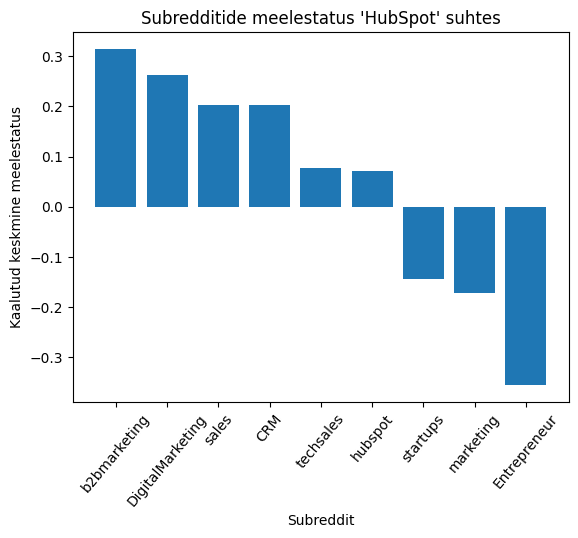

In [ ]:
import matplotlib.pyplot as plt

data = all_summaries_target_data.sort_values("weighted_avg_sentiment", ascending=False)
plt.bar(range(len(data)), data["weighted_avg_sentiment"])
plt.xticks(range(len(data)), data["subreddit_name"], rotation=50)
plt.xlabel("Subreddit")
plt.ylabel("Kaalutud keskmine meelestatus")
plt.title(f"Subredditide meelestatus '{target}' suhtes")

